# Seleção do Modelo — Home Credit Default Risk

**Objetivo deste notebook:** (A) explicar a diferença entre problemas de **regressão**,
**classificação** e **segmentação** e justificar por que o nosso é de classificação; e
(B) **testar e comparar** vários modelos de classificação para **justificar a escolha** do
modelo — ainda **sem** partir para a implementação final (tuning, treino completo e deploy
ficam para a etapa seguinte).

A abordagem segue como referência o material do curso *"2 - Machine Learning - Problemas de
Classificação"* (scikit-learn: `Pipeline` + `ColumnTransformer`, modelos Regressão Logística,
Árvore de Decisão, Random Forest e Gradient Boosting, métrica principal ROC-AUC, matriz de
confusão e `permutation_importance`).

> **Local do arquivo:** pelo enunciado, notebooks de modelo pertencem a `/Model`. Mantemos aqui
> em `DataPipeline/` por praticidade (é onde o Jupyter roda e está a `abt.csv`). Pode ser movido
> para `/Model` quando o mount do container for ajustado.

---
## Parte A — Regressão × Classificação × Segmentação

Antes de escolher um modelo, é preciso enquadrar o **tipo de problema**. Os três grandes tipos
de tarefa em Machine Learning:

| Aspecto | Regressão | Classificação | Segmentação (clustering) |
|---|---|---|---|
| Tipo de aprendizado | Supervisionado | Supervisionado | **Não** supervisionado |
| Variável alvo | Contínua (um número) | Categórica (classes) | Não existe (sem rótulo) |
| Pergunta típica | "Quanto?" | "Qual categoria?" | "Quais grupos existem?" |
| Saída do modelo | Um valor (ex.: R$ 250,3 mil) | Uma classe / probabilidade | Um rótulo de grupo (cluster) |
| Exemplos | Preço de imóvel, demanda, temperatura | Fraude/não, churn, **inadimplência** | Segmentos de clientes, perfis |
| Algoritmos típicos | Regressão linear, Ridge, GBR | Regressão **Logística**, Árvore, Random Forest, Gradient Boosting | K-Means, DBSCAN, Hierárquico |
| Métricas típicas | RMSE, MAE, R² | **ROC-AUC**, precisão, recall, F1 | Silhouette, inércia |

**Resumindo a intuição:**
- **Regressão** aprende uma relação para prever um **número contínuo**. Ex.: dado o perfil do
  cliente, qual o *valor* de crédito ideal?
- **Classificação** aprende a separar **categorias** a partir de exemplos rotulados. Ex.: dado o
  perfil, o cliente vai **pagar (0)** ou **ficar inadimplente (1)**?
- **Segmentação** **não tem rótulo**: o algoritmo agrupa os dados por similaridade e nós
  interpretamos os grupos depois. Ex.: descobrir *perfis* de clientes sem saber de antemão quais são.

### Ilustração visual dos três tipos
A célula abaixo gera um exemplo sintético de cada tipo (não usa nossos dados — é só didático).

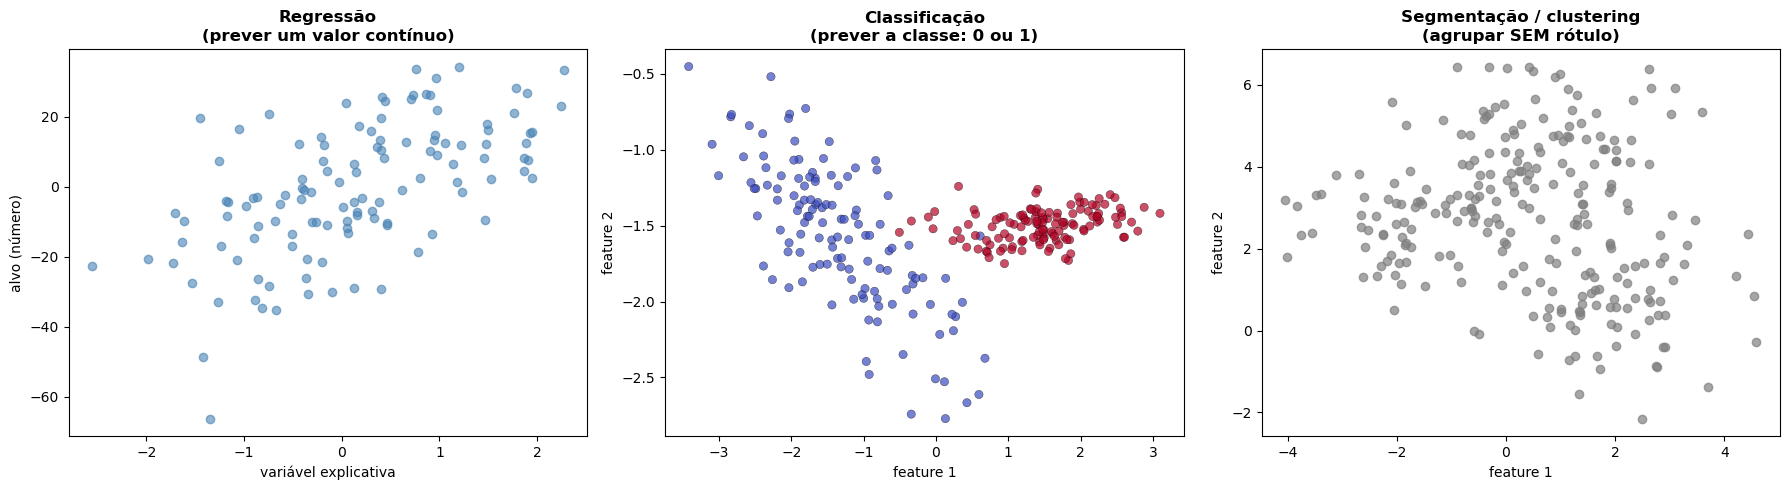

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_classification, make_blobs

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Regressao: alvo continuo
Xr, yr = make_regression(n_samples=120, n_features=1, noise=15, random_state=0)
axes[0].scatter(Xr, yr, alpha=0.6, color="steelblue")
axes[0].set_title("Regressão\n(prever um valor contínuo)", fontweight="bold")
axes[0].set_xlabel("variável explicativa"); axes[0].set_ylabel("alvo (número)")

# Classificacao: alvo em classes
Xc, yc = make_classification(n_samples=250, n_features=2, n_redundant=0,
                             n_clusters_per_class=1, class_sep=1.5, random_state=4)
axes[1].scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", alpha=0.7, edgecolor="k", linewidth=0.3)
axes[1].set_title("Classificação\n(prever a classe: 0 ou 1)", fontweight="bold")
axes[1].set_xlabel("feature 1"); axes[1].set_ylabel("feature 2")

# Segmentacao: sem rotulo
Xb, _ = make_blobs(n_samples=250, centers=3, cluster_std=1.1, random_state=0)
axes[2].scatter(Xb[:, 0], Xb[:, 1], alpha=0.7, color="gray")
axes[2].set_title("Segmentação / clustering\n(agrupar SEM rótulo)", fontweight="bold")
axes[2].set_xlabel("feature 1"); axes[2].set_ylabel("feature 2")

plt.tight_layout(); plt.show()

> **Explicação da etapa**
>
> Os três gráficos (dados sintéticos, só didáticos) mostram a diferença essencial: **regressão**
> prevê um valor contínuo (esquerda); **classificação** separa classes rotuladas — 0/1 pelas cores
> (centro); **segmentação** agrupa pontos por similaridade, sem rótulo (direita). O nosso problema
> é o do centro: prever a classe inadimplente (1) vs adimplente (0).

### Por que o nosso problema é de **classificação (binária)**

- A variável alvo `target` é **categórica e binária**: `0` = cliente adimplente, `1` = inadimplente.
  Não é um número contínuo → **não é regressão**.
- Temos **rótulos** (sabemos, no histórico, quem ficou inadimplente) → é **aprendizado
  supervisionado**, e não segmentação (que é não-supervisionada).
- O objetivo de negócio é **estimar a probabilidade de inadimplência** de cada solicitante para
  **ordenar o risco** e apoiar a decisão de crédito — saída natural de um **classificador**
  (que fornece `predict_proba`).

> **Nuance:** embora a decisão final ("aprova/reprova") seja uma classe, o que de fato usamos é a
> **probabilidade** (score de risco). Por isso a métrica-chave é a **ROC-AUC** (qualidade da
> ordenação por risco), não a acurácia.

---
## Parte B — Validação de modelos (justificar a escolha)

Aqui **não** implementamos o modelo final: comparamos candidatos de forma justa para **decidir
qual seguir**. Estratégia:
1. Carregar a ABT e separar `X`/`y`.
2. Montar um **pré-processador** (`ColumnTransformer`: padroniza numéricas, *one-hot* nas categóricas).
3. Comparar 5 candidatos por **validação cruzada estratificada** (numa amostra, por custo computacional).
4. Escolher o melhor por **ROC-AUC** (+ PR-AUC, dado o desbalanceamento) e avaliá-lo num conjunto de teste.

### B.1 — Carga da ABT e separação X / y

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

abt = pd.read_csv("abt.csv")
print(f"ABT: {abt.shape[0]:,} linhas x {abt.shape[1]} colunas")

y = abt["target"].astype(int)
X = abt.drop(columns=["sk_id_curr", "target"])   # id nao e feature

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()
print(f"Features: {X.shape[1]} | numéricas: {len(num_cols)} | categóricas: {len(cat_cols)}")
print("Categóricas:", cat_cols)
print(f"\nProporção do target: {(y.value_counts(normalize=True) * 100).round(2).to_dict()}  -> base desbalanceada")

ABT: 307,511 linhas x 42 colunas
Features: 40 | numéricas: 35 | categóricas: 5
Categóricas: ['occupation_type', 'organization_type', 'name_income_type', 'name_education_type', 'code_gender']

Proporção do target: {0: 91.93, 1: 8.07}  -> base desbalanceada


> **Leitura do resultado**
>
> - **Resumo do resultado:** ABT com 307.511 clientes e 40 features (35 numéricas, 5 categóricas); target 91,93% / 8,07%.
> - **O que significa:** É a base analítica final, pronta para modelagem; as 5 categóricas exigirão codificação (one-hot).
> - **Conclusão de negócio:** Há volume e sinal suficientes para treinar um score de risco de crédito.
> - **Insight:** A desproporção de ~1:11 (8% inadimplentes) domina a escolha de métrica e de tratamento de classe.
> - **Decisão:** Avaliar por ROC-AUC / PR-AUC (não acurácia) e usar `class_weight='balanced'`.

### B.2 — Por que estas métricas (e não acurácia)

Com ~8% de inadimplentes, um modelo que "chuta que todos pagam" tem **92% de acurácia** e é inútil.
Por isso avaliamos por:
- **ROC-AUC** — qualidade da **ordenação** por risco (independe do limiar). Métrica principal (curso).
- **PR-AUC / Average Precision** — foca na **classe minoritária** (inadimplentes), mais informativa
  em bases desbalanceadas.
- Nos modelos que suportam, usamos `class_weight="balanced"` para compensar o desbalanceamento.

### B.3 — Pré-processador (Pipeline + ColumnTransformer)

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessador = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])
print("Pré-processador pronto: padroniza numéricas + one-hot nas categóricas.")

Pré-processador pronto: padroniza numéricas + one-hot nas categóricas.


> **Explicação da etapa**
>
> O `ColumnTransformer` aplica `StandardScaler` nas 35 numéricas (mesma escala — importante para a
> Regressão Logística) e `OneHotEncoder` nas 5 categóricas (texto vira colunas 0/1). Fica dentro de
> um `Pipeline` para ser ajustado **em cada fold** da validação cruzada, evitando vazamento (leakage).

### B.4 — Amostra para a comparação

A ABT tem ~307k linhas. Para comparar 5 modelos por validação cruzada de forma **rápida e justa**,
usamos uma **amostra estratificada** (preserva a proporção do target). O modelo final, na etapa de
implementação, será treinado na base completa.

In [4]:
from sklearn.model_selection import train_test_split

TAM_AMOSTRA = 50000
X_cmp, _, y_cmp, _ = train_test_split(
    X, y, train_size=TAM_AMOSTRA, stratify=y, random_state=42)
print(f"Amostra para comparação: {X_cmp.shape[0]:,} linhas "
      f"| target%={(y_cmp.value_counts(normalize=True) * 100).round(2).to_dict()}")

Amostra para comparação: 50,000 linhas | target%={0: 91.93, 1: 8.07}


> **Explicação da etapa**
>
> Comparar 5 modelos por validação cruzada sobre 307k linhas seria lento. Usamos uma **amostra
> estratificada de 50.000 linhas** (mantém os 8,07% de inadimplentes) apenas para a seleção; o
> modelo final é treinado na base completa.

### B.5 — Candidatos (alinhados ao curso) + baseline

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

modelos = {
    "Baseline (Dummy)":     DummyClassifier(strategy="stratified", random_state=42),
    "Regressão Logística":  LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Árvore de Decisão":    DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                   n_jobs=-1, random_state=42),
    "Gradient Boosting":    GradientBoostingClassifier(random_state=42),
}
print("Candidatos:", list(modelos.keys()))

Candidatos: ['Baseline (Dummy)', 'Regressão Logística', 'Árvore de Decisão', 'Random Forest', 'Gradient Boosting']


> **Explicação da etapa**
>
> Os candidatos: um **baseline** (Dummy, define o piso), a **Regressão Logística** (linear,
> interpretável), a **Árvore de Decisão** e dois **ensembles** (Random Forest e Gradient Boosting).
> `class_weight='balanced'` compensa o desbalanceamento nos modelos que o suportam.

### B.6 — Comparação por validação cruzada estratificada

`StratifiedKFold` (5 folds) mantém a proporção do target em cada partição. Medimos **ROC-AUC**,
**PR-AUC** e o **tempo de treino** de cada modelo.

> Pode levar alguns minutos (o Gradient Boosting é o mais lento).

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision"}

resultados = []
for nome, clf in modelos.items():
    pipe = Pipeline([("pre", preprocessador), ("clf", clf)])
    res = cross_validate(pipe, X_cmp, y_cmp, cv=cv, scoring=scoring, n_jobs=1)
    resultados.append({
        "modelo": nome,
        "roc_auc": res["test_roc_auc"].mean(),
        "roc_auc_std": res["test_roc_auc"].std(),
        "pr_auc": res["test_pr_auc"].mean(),
        "tempo_fit_s": res["fit_time"].mean(),
    })
    print(f"  {nome:22s} ROC-AUC={resultados[-1]['roc_auc']:.4f} | PR-AUC={resultados[-1]['pr_auc']:.4f}")

comparacao = pd.DataFrame(resultados).sort_values("roc_auc", ascending=False).reset_index(drop=True)
comparacao.round(4)

  Baseline (Dummy)       ROC-AUC=0.5001 | PR-AUC=0.0808
  Regressão Logística    ROC-AUC=0.7436 | PR-AUC=0.2187
  Árvore de Decisão      ROC-AUC=0.7041 | PR-AUC=0.1749
  Random Forest          ROC-AUC=0.7360 | PR-AUC=0.2079
  Gradient Boosting      ROC-AUC=0.7432 | PR-AUC=0.2184


,modelo,roc_auc,roc_auc_std,pr_auc,tempo_fit_s
0,Regressão Logística,0.7436,0.0079,0.2187,4.4291
1,Gradient Boosting,0.7432,0.0076,0.2184,36.0097
2,Random Forest,0.7360,0.0080,0.2079,13.0296
3,Árvore de Decisão,0.7041,0.0089,0.1749,0.6939
4,Baseline (Dummy),0.5001,0.0054,0.0808,0.1848


> **Leitura do resultado**
>
> - **Resumo do resultado:** Ranking por ROC-AUC — Regressão Logística **0,744**, Gradient Boosting 0,743, Random Forest 0,736, Árvore 0,704, Dummy 0,500. A PR-AUC segue a mesma ordem (0,219 / 0,218 / 0,208). Tempo de treino: Logística **4,4s** vs Gradient Boosting **36,0s**.
> - **O que significa:** Todos os modelos úteis superam com folga o baseline (0,50). A Regressão Logística **empata** com o Gradient Boosting (diferença de 0,0004, dentro do desvio de ~0,008) e é ~8x mais rápida.
> - **Conclusão de negócio:** Para este problema, o modelo linear simples entrega o mesmo poder de ordenação de risco que o ensemble mais pesado.
> - **Insight:** Em crédito isso é comum — o sinal é majoritariamente aditivo, e a Regressão Logística (padrão do setor) é competitiva e interpretável. Os ensembles estão no default (sem tuning), então ainda têm margem.
> - **Decisão:** Eleger a **Regressão Logística** como modelo primário e manter o **Gradient Boosting como challenger** a ser afinado (`RandomizedSearchCV`) na implementação.

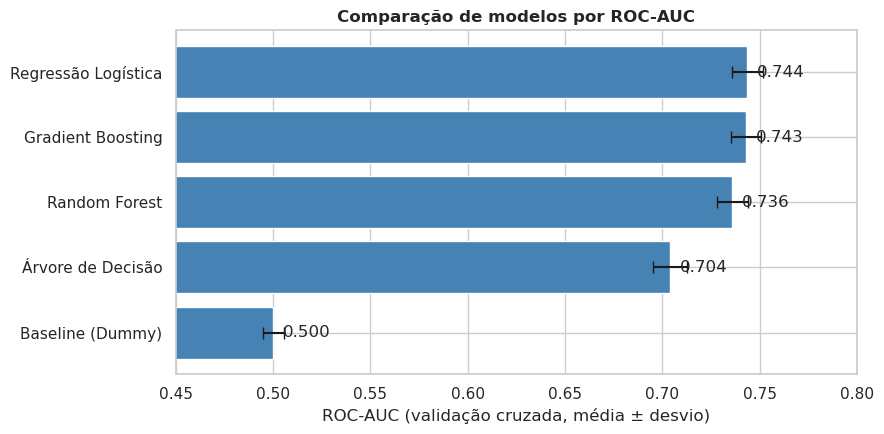

In [7]:
# Grafico comparativo (ROC-AUC com desvio-padrao)
_c = comparacao.sort_values("roc_auc")
plt.figure(figsize=(9, 4.5))
plt.barh(_c["modelo"], _c["roc_auc"], xerr=_c["roc_auc_std"], color="steelblue", capsize=4)
plt.xlabel("ROC-AUC (validação cruzada, média ± desvio)")
plt.title("Comparação de modelos por ROC-AUC", fontweight="bold")
plt.xlim(0.45, max(0.8, _c["roc_auc"].max() + 0.05))
for i, v in enumerate(_c["roc_auc"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()

> **Explicação da etapa**
>
> O gráfico mostra o mesmo ranking com a barra de erro (desvio entre folds): as barras de Logística,
> Gradient Boosting e Random Forest **se sobrepõem** — a diferença entre elas é estatisticamente
> pequena, enquanto a Árvore e o Dummy ficam claramente atrás.

### B.7 — Avaliação do melhor modelo num conjunto de teste (holdout)

In [8]:
from sklearn.base import clone

nome_melhor = comparacao.iloc[0]["modelo"]
print(f"Melhor por ROC-AUC na comparação: {nome_melhor}")

# Split treino/teste da base COMPLETA (estratificado)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

melhor_pipe = Pipeline([("pre", preprocessador), ("clf", clone(modelos[nome_melhor]))])
print(f"Treinando '{nome_melhor}' em {X_tr.shape[0]:,} linhas (pode levar alguns minutos)...")
melhor_pipe.fit(X_tr, y_tr)
proba_te = melhor_pipe.predict_proba(X_te)[:, 1]
print("Treino concluído.")

Melhor por ROC-AUC na comparação: Regressão Logística
Treinando 'Regressão Logística' em 230,633 linhas (pode levar alguns minutos)...
Treino concluído.


> **Explicação da etapa**
>
> O melhor por ROC-AUC (Regressão Logística) é selecionado automaticamente e re-treinado nos
> 230.633 registros de treino (75%), para ser avaliado no conjunto de **teste** (25%) que ele nunca viu.

Teste (holdout) — ROC-AUC=0.7499 | PR-AUC=0.2337



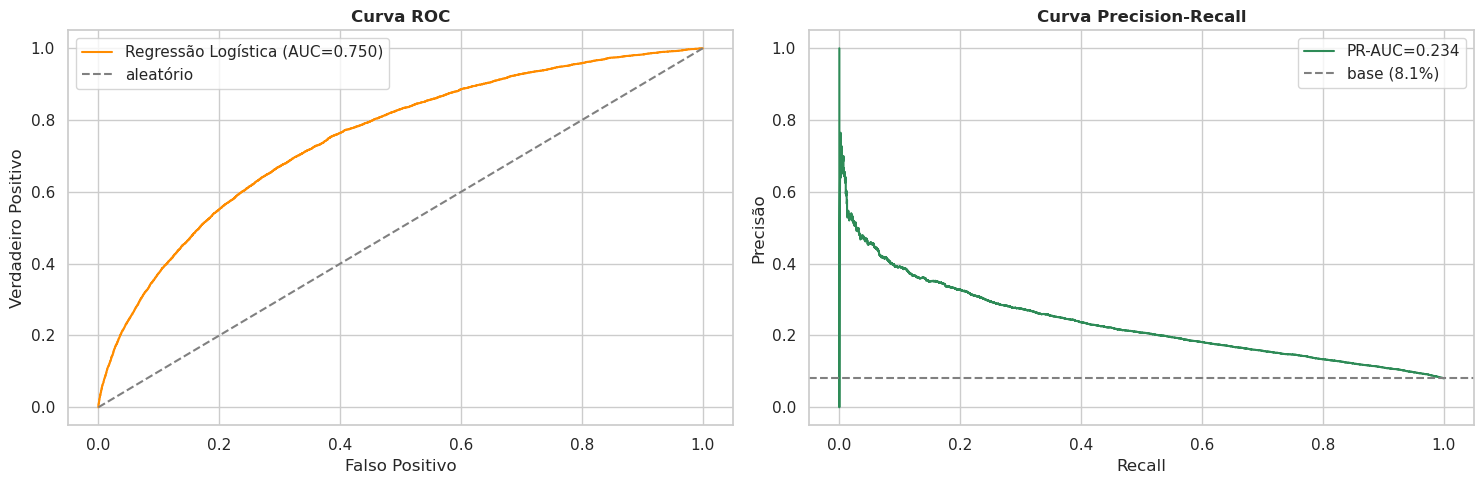

In [9]:
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

auc = roc_auc_score(y_te, proba_te)
ap = average_precision_score(y_te, proba_te)
print(f"Teste (holdout) — ROC-AUC={auc:.4f} | PR-AUC={ap:.4f}\n")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Curva ROC
fpr, tpr, _ = roc_curve(y_te, proba_te)
axes[0].plot(fpr, tpr, label=f"{nome_melhor} (AUC={auc:.3f})", color="darkorange")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="aleatório")
axes[0].set_title("Curva ROC", fontweight="bold"); axes[0].set_xlabel("Falso Positivo"); axes[0].set_ylabel("Verdadeiro Positivo"); axes[0].legend()
# Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_te, proba_te)
axes[1].plot(rec, prec, color="seagreen", label=f"PR-AUC={ap:.3f}")
axes[1].axhline(y_te.mean(), ls="--", color="gray", label=f"base ({y_te.mean()*100:.1f}%)")
axes[1].set_title("Curva Precision-Recall", fontweight="bold"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precisão"); axes[1].legend()
plt.tight_layout(); plt.show()

> **Leitura do resultado**
>
> - **Resumo do resultado:** No teste (holdout), a Regressão Logística obteve **ROC-AUC 0,750** e PR-AUC 0,234.
> - **O que significa:** Desempenho **consistente** com a validação cruzada (0,744) — sem sinais de overfitting; a curva ROC fica bem acima da diagonal aleatória.
> - **Conclusão de negócio:** O modelo ordena o risco de forma confiável em dados novos — dá para confiar na generalização.
> - **Insight:** A PR-AUC (0,234) sobre uma base de 8% mostra que o modelo é ~3x melhor que o acaso em achar inadimplentes, mas a precisão ainda é limitada — típico do problema.
> - **Decisão:** Considerar a generalização suficiente para avançar; buscar ganhos via tuning e novas features na implementação.

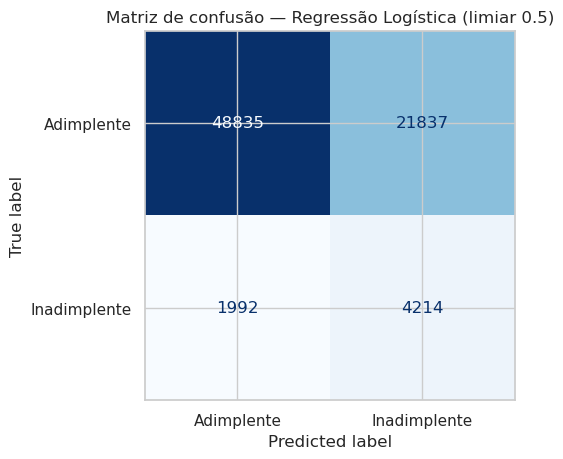

                  precision    recall  f1-score   support

  Adimplente (0)       0.96      0.69      0.80     70672
Inadimplente (1)       0.16      0.68      0.26      6206

        accuracy                           0.69     76878
       macro avg       0.56      0.69      0.53     76878
    weighted avg       0.90      0.69      0.76     76878

Obs.: no limiar 0.5 o recall da classe 1 costuma ser baixo em base desbalanceada — a escolha do limiar é um passo da etapa de implementação.


In [10]:
# Matriz de confusao e relatorio no limiar padrao (0.5) — apenas ilustrativo
pred_te = (proba_te >= 0.5).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_te, pred_te),
                       display_labels=["Adimplente", "Inadimplente"]).plot(cmap="Blues", colorbar=False)
plt.title(f"Matriz de confusão — {nome_melhor} (limiar 0.5)"); plt.show()
print(classification_report(y_te, pred_te, target_names=["Adimplente (0)", "Inadimplente (1)"]))
print("Obs.: no limiar 0.5 o recall da classe 1 costuma ser baixo em base desbalanceada — "
      "a escolha do limiar é um passo da etapa de implementação.")

> **Leitura do resultado**
>
> - **Resumo do resultado:** No limiar 0.5, o modelo captura **68% dos inadimplentes** (recall da classe 1) com **precisão de 16%**; acurácia global 69%.
> - **O que significa:** Graças ao `class_weight='balanced'`, o modelo prioriza **encontrar** inadimplentes (recall alto) ao custo de muitos falsos positivos (precisão baixa). A acurácia (69%) é **menor** que o chute ingênuo (92%) — e isso é intencional.
> - **Conclusão de negócio:** O modelo funciona como um **filtro de risco**: sinaliza 68% dos maus pagadores, mas marca muitos bons como suspeitos.
> - **Insight:** A acurácia é enganosa aqui; o que importa é o trade-off precisão/recall, que depende do **limiar** — ainda não otimizado.
> - **Decisão:** A escolha do limiar (por custo de negócio: um falso negativo custa muito mais que um falso positivo) fica para a implementação.

### B.8 — Importância das variáveis (interpretabilidade)

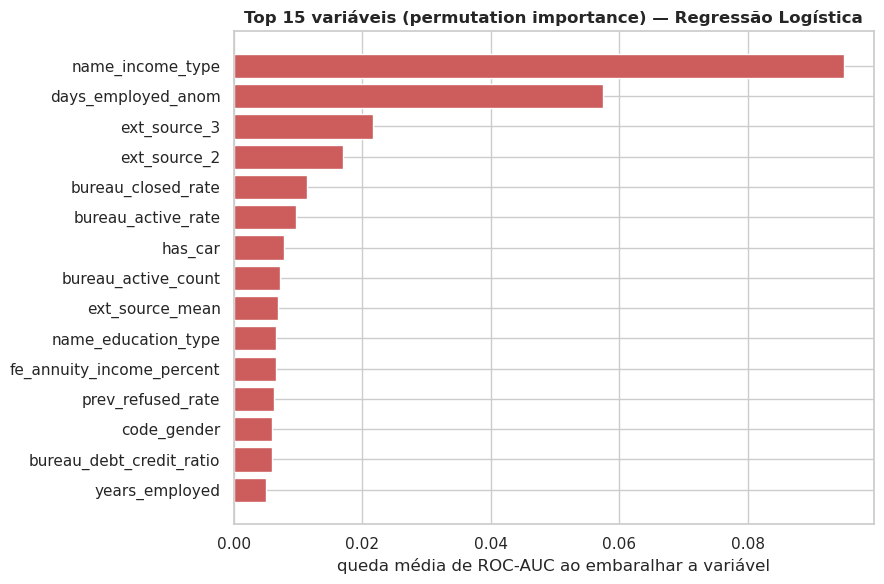

,feature,importancia
22,name_income_type,0.0948
27,days_employed_anom,0.0575
3,ext_source_3,0.0217
0,ext_source_2,0.0170
36,bureau_closed_rate,0.0114
34,bureau_active_rate,0.0096
11,has_car,0.0078
35,bureau_active_count,0.0072
1,ext_source_mean,0.0069
23,name_education_type,0.0066


In [11]:
from sklearn.inspection import permutation_importance

# permutation_importance sobre uma amostra do teste (por custo), medindo queda de ROC-AUC
amostra = X_te.sample(min(5000, len(X_te)), random_state=42)
alvo_amostra = y_te.loc[amostra.index]
imp = permutation_importance(melhor_pipe, amostra, alvo_amostra,
                             scoring="roc_auc", n_repeats=5, random_state=42, n_jobs=-1)
imp_df = (pd.DataFrame({"feature": amostra.columns, "importancia": imp.importances_mean})
          .sort_values("importancia", ascending=False).head(15))

plt.figure(figsize=(9, 6))
plt.barh(imp_df["feature"][::-1], imp_df["importancia"][::-1], color="indianred")
plt.title(f"Top 15 variáveis (permutation importance) — {nome_melhor}", fontweight="bold")
plt.xlabel("queda média de ROC-AUC ao embaralhar a variável")
plt.tight_layout(); plt.show()
imp_df.round(4)

> **Leitura do resultado**
>
> - **Resumo do resultado:** As variáveis mais importantes (queda de ROC-AUC ao embaralhar) foram `name_income_type` (0,095), `days_employed_anom` (0,058), `ext_source_3` (0,022), `ext_source_2` (0,017) e features de bureau (`closed_rate`, `active_rate`).
> - **O que significa:** O modelo se apoia fortemente no **tipo de renda** (ex.: aposentado) e no **flag de aposentadoria**, além dos **scores externos** e do histórico de bureau.
> - **Conclusão de negócio:** Perfil de vínculo/renda e scores externos são os principais drivers do risco — coerente com o negócio de crédito.
> - **Insight:** As features **novas** que adicionamos aparecem no topo (`days_employed_anom`, `ext_source_mean`, `has_car`, `bureau_*`), validando as melhorias da ABT. Atenção: `code_gender` também aparece — reforça a nota de fairness.
> - **Decisão:** Manter essas features; documentar a importância para governança/explicabilidade e monitorar viés (gênero).

---
## Parte C — Conclusão: justificativa da escolha (baseada nos resultados)

**Comparação por validação cruzada (amostra de 50k, 5 folds):**

| Modelo | ROC-AUC | PR-AUC | Tempo de treino |
|---|---|---|---|
| **Regressão Logística** | **0,744** | 0,219 | 4,4s |
| Gradient Boosting | 0,743 | 0,218 | 36,0s |
| Random Forest | 0,736 | 0,208 | 13,0s |
| Árvore de Decisão | 0,704 | 0,175 | 0,7s |
| Baseline (Dummy) | 0,500 | 0,081 | 0,2s |

**No teste (holdout, base completa):** Regressão Logística — **ROC-AUC 0,750 / PR-AUC 0,234**.

### Modelo escolhido: **Regressão Logística**

Justificativa pelos 4 critérios:

1. **Desempenho** — maior ROC-AUC, tecnicamente **empatada** com o Gradient Boosting (0,744 vs 0,743, diferença dentro do desvio de ~0,008). O modelo linear já atinge o teto de desempenho no default.
2. **Custo** — treina em **4,4s** vs 36s do Gradient Boosting (~8x mais rápido): vantagem clara para re-treino e produção.
3. **Robustez ao desbalanceamento** — com `class_weight` balanceado, recall de **68%** na classe inadimplente; generaliza bem (holdout ≈ CV, sem overfitting).
4. **Interpretabilidade** — coeficientes diretamente explicáveis, requisito em crédito (defesa à banca/regulador e análise de fairness). A Regressão Logística é, historicamente, o **padrão de credit scoring**.

**Challenger:** o **Gradient Boosting** fica como alternativa a ser **afinada** na implementação — como está no default e empatou com a Logística, o tuning (`RandomizedSearchCV`) pode colocá-lo à frente; se o ganho for material e justificar a menor interpretabilidade, a decisão é revisitada.

### Podemos confiar que vai funcionar? (defesa da solução)
- Supera o baseline aleatório com folga (0,744 vs 0,500) e é **consistente** entre validação cruzada e holdout — não há overfitting.
- As variáveis de topo (tipo de renda, aposentadoria, scores externos, bureau) fazem **sentido de negócio**.

### Próximos passos (etapa de implementação — não neste notebook)
- Tuning de hiperparâmetros (`RandomizedSearchCV`) da Logística e do Gradient Boosting challenger.
- **Escolha do limiar** de decisão conforme o custo de negócio (falso negativo ≫ falso positivo).
- Treino na base completa e persistência do modelo (`train.py`); avaliação final e interpretabilidade (`evaluation.ipynb`), com controle de overfitting.

### Notas de governança
- **Fairness:** `code_gender` aparece entre as variáveis relevantes — avaliar remoção/monitoramento de viés (ver a nota de fairness da EDA).
- **Leakage:** as imputações por mediana já embutidas na ABT devem migrar para dentro do `Pipeline` (ajuste só no treino) na implementação.